# Algorithm family and variant comparison

Focus: compare algorithm families, variants (risk / reweight / vanilla), and CVaR type to surface structural advantages.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlepad"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()


DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / 'combined_wide.csv')
combined = combined.drop(columns=[c for c in ['Unnamed: 0'] if c in combined.columns])
combined['seed'] = combined['seed'].astype(str)
metrics = [c for c in combined.columns if c.startswith('pass@') or c == 'avg@32']


DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




In [2]:

# Tag families / variants

def family(algo: str):
    if 'GRPO' in algo:
        return 'GRPO'
    if 'PPO' in algo:
        return 'PPO'
    return 'Other'


def variant(algo: str):
    if 'risk' in algo:
        return 'risk'
    if 'reweight' in algo:
        return 'reweight'
    return 'vanilla'


def cvar_type(algo: str):
    if 'cvarlower' in algo:
        return 'cvarlower'
    if 'cvarupper' in algo:
        return 'cvarupper'
    return 'none'

combined['family'] = combined['algorithm'].apply(family)
combined['variant'] = combined['algorithm'].apply(variant)
combined['cvar'] = combined['algorithm'].apply(cvar_type)

mean_df = combined.groupby(['Step', 'algorithm', 'family', 'variant', 'cvar'], as_index=False)[metrics].mean()
final_step = int(mean_df['Step'].max())
final_df = mean_df[mean_df['Step'] == final_step]
passk_metrics = [m for m in metrics if m.startswith('pass@')]


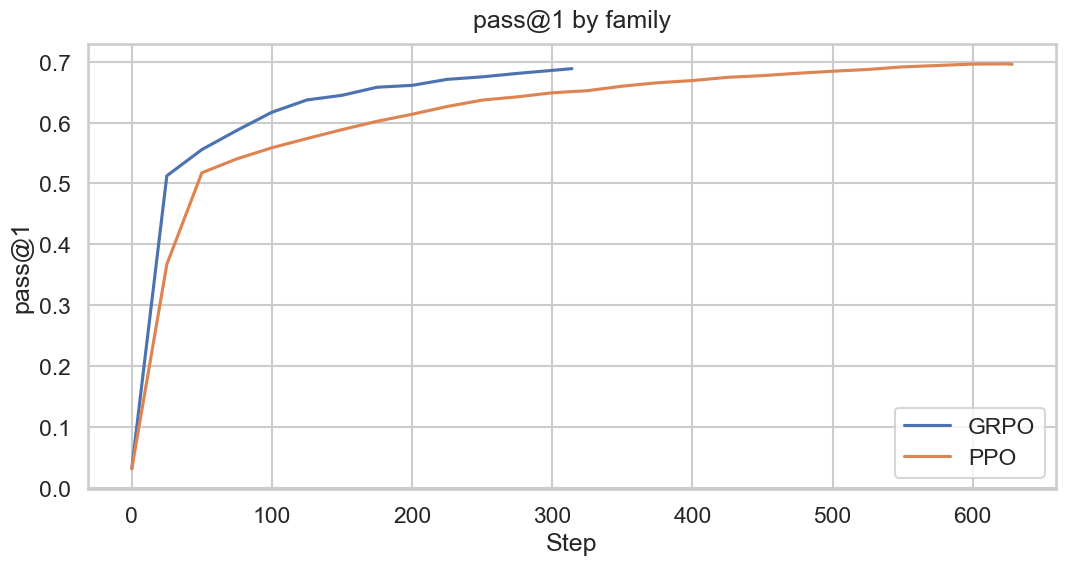

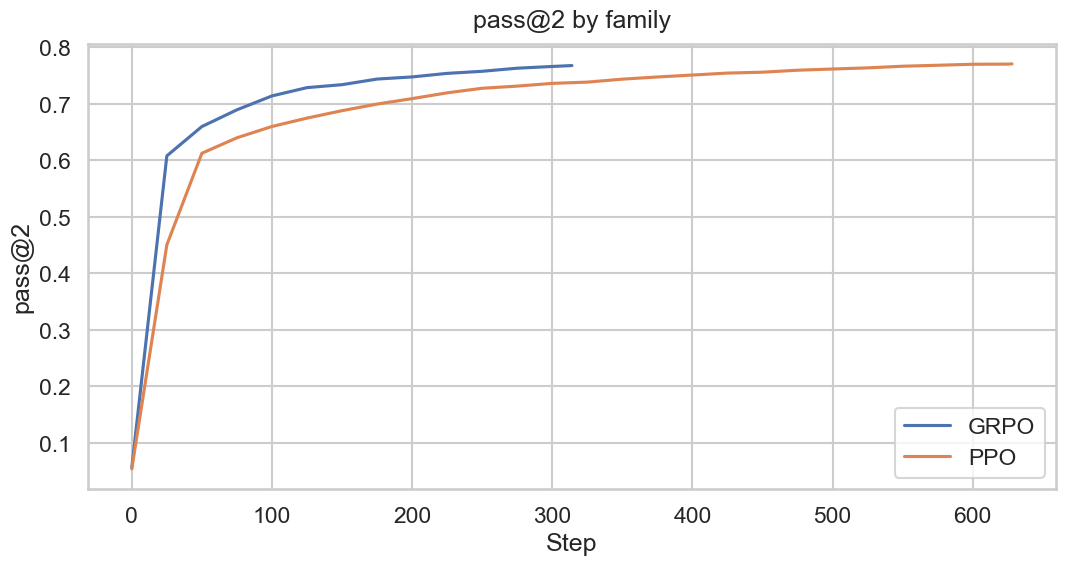

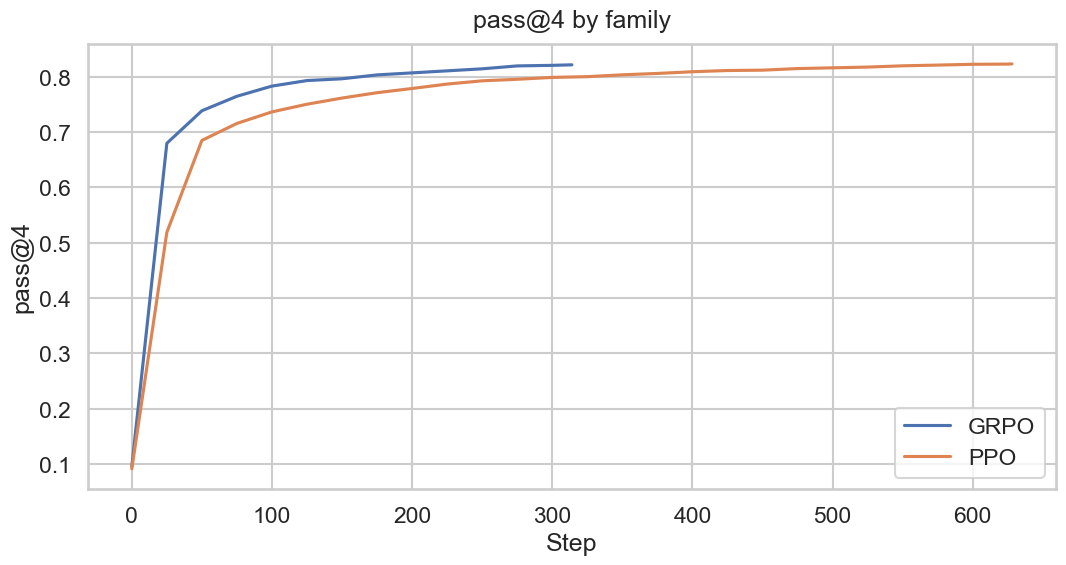

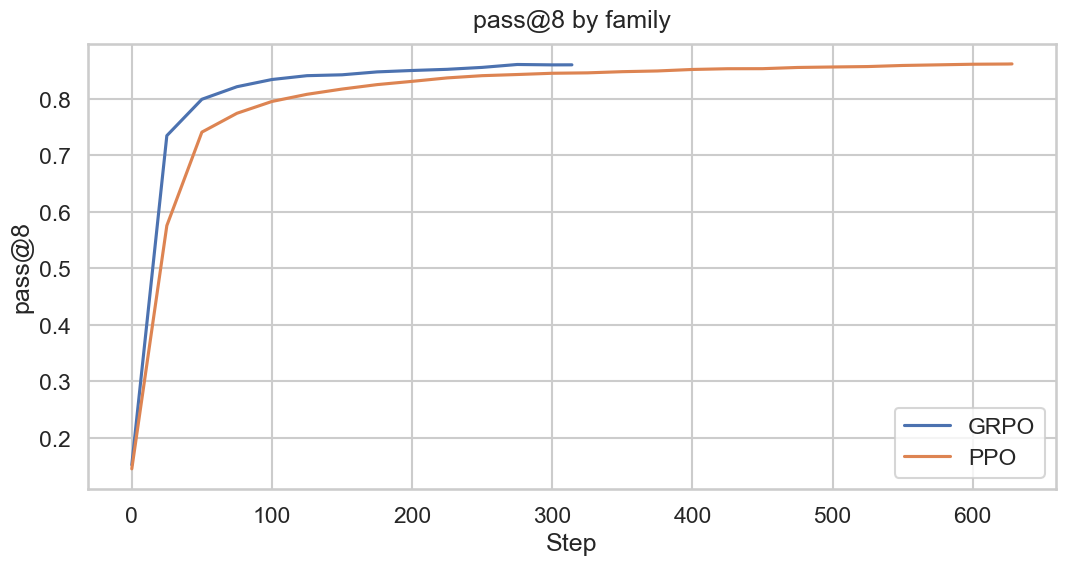

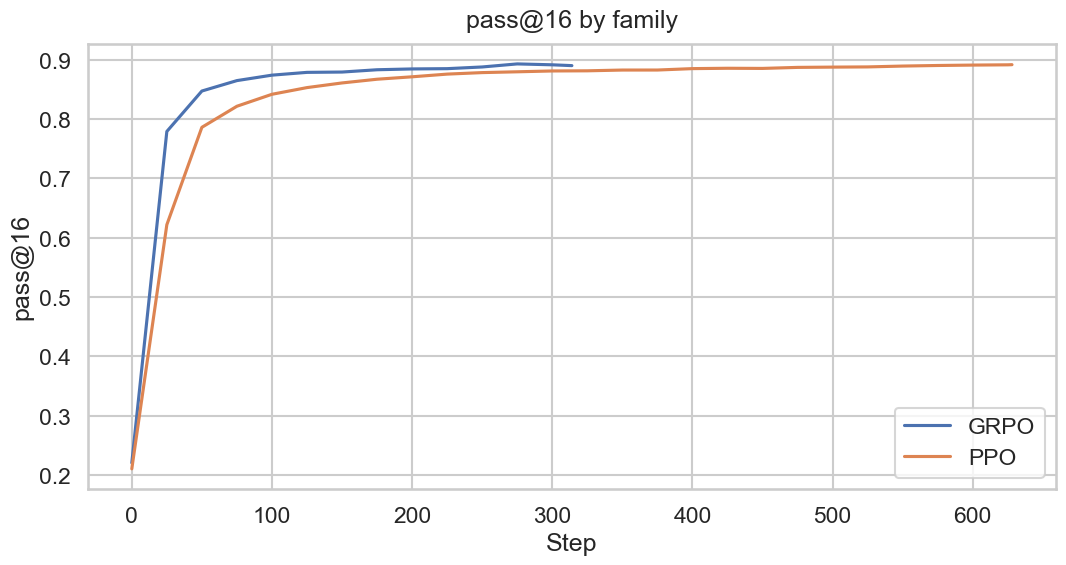

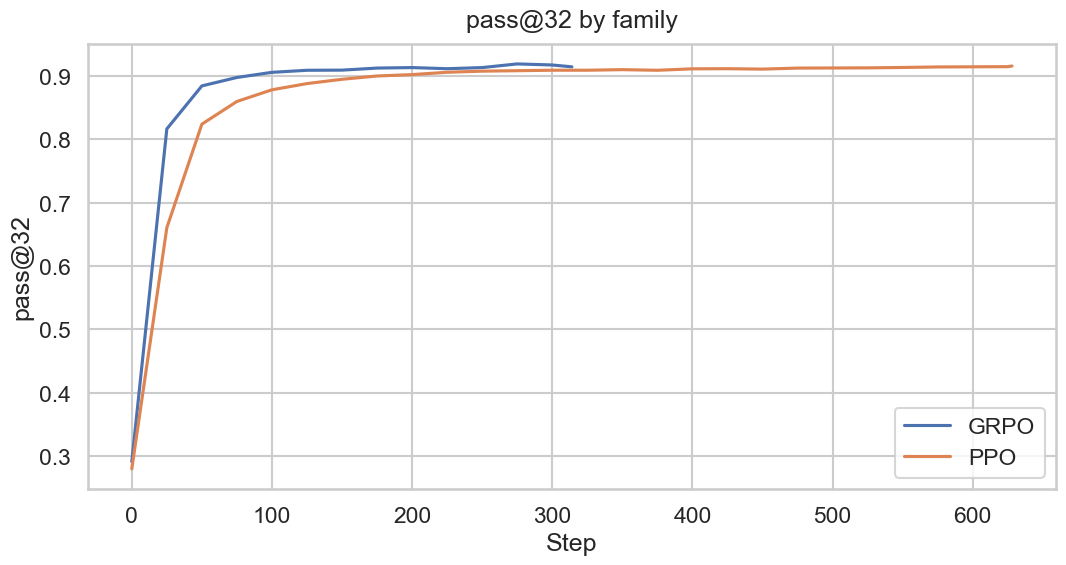

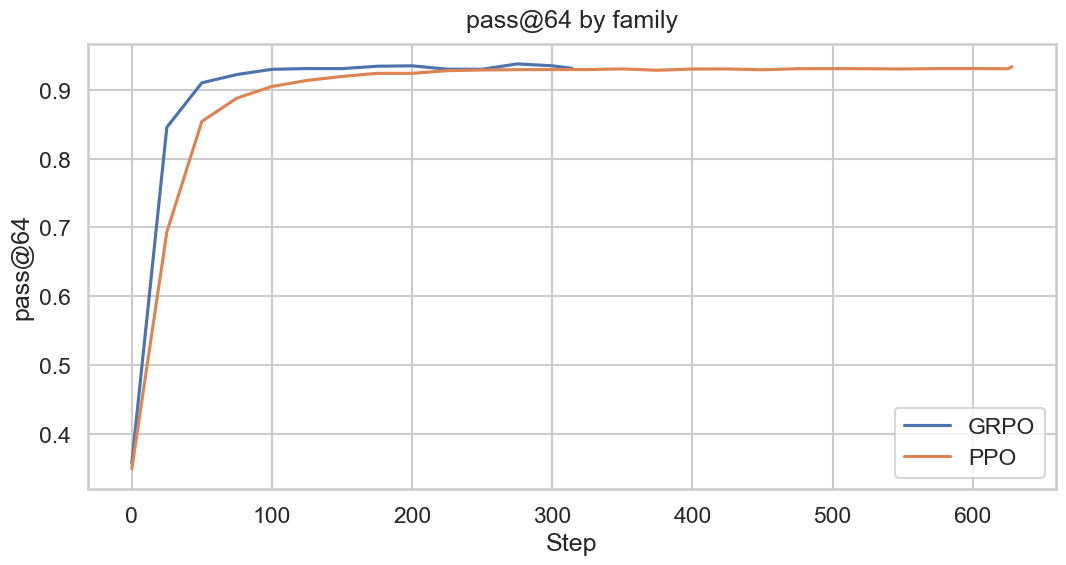

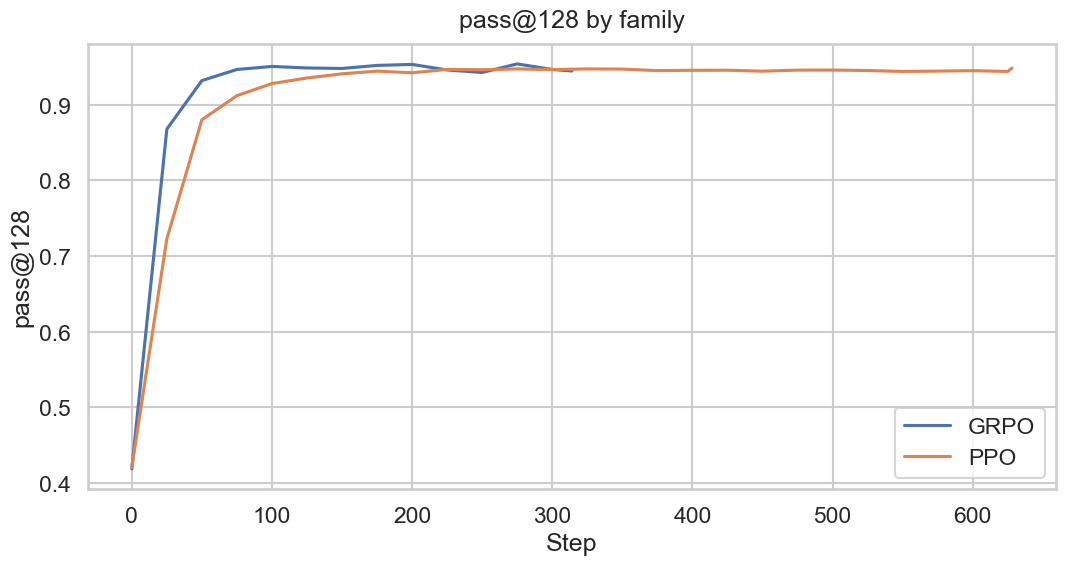

In [3]:

# Plot set A: family learning curves
for metric in passk_metrics:
    plt.figure()
    family_mean = mean_df.groupby(['Step', 'family'], as_index=False)[metric].mean()
    for fam, sub in family_mean.groupby('family'):
        plt.plot(sub['Step'], sub[metric], label=fam)
    plt.title(f"{metric} by family")
    plt.xlabel('Step')
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


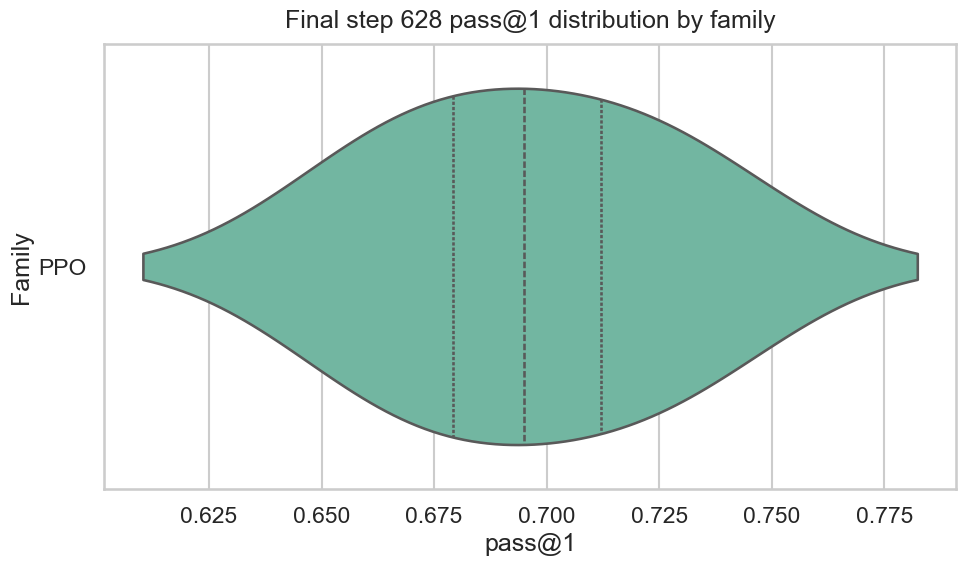

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


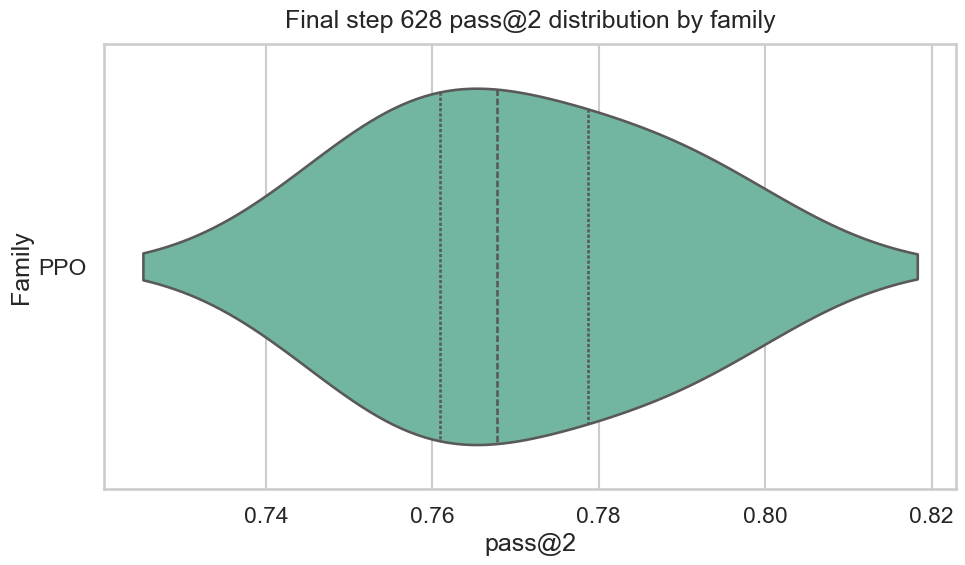

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


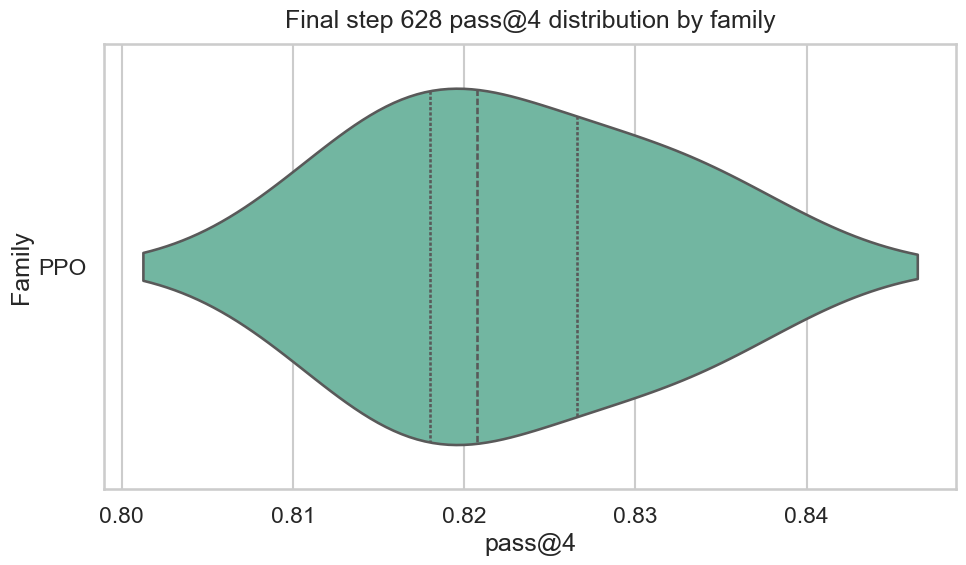

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


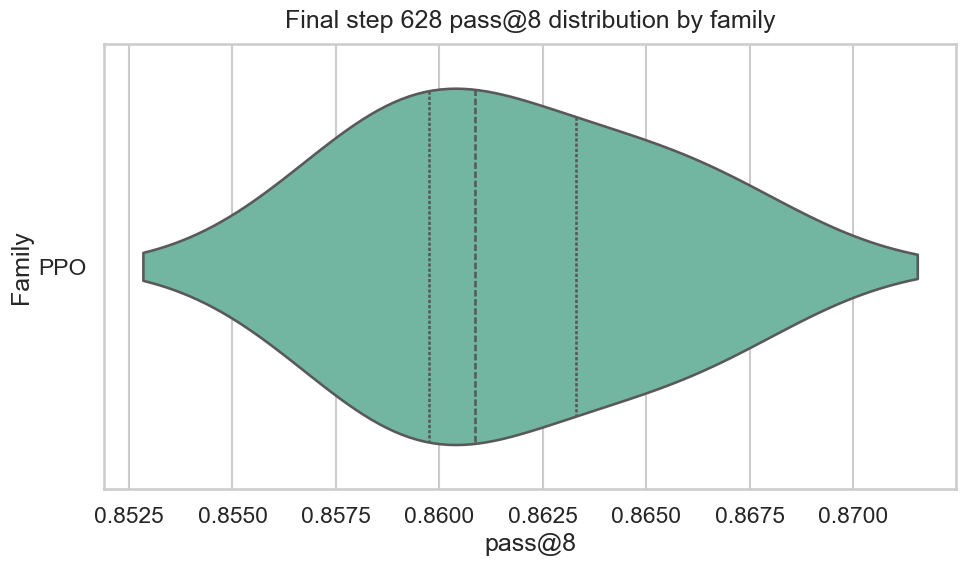

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


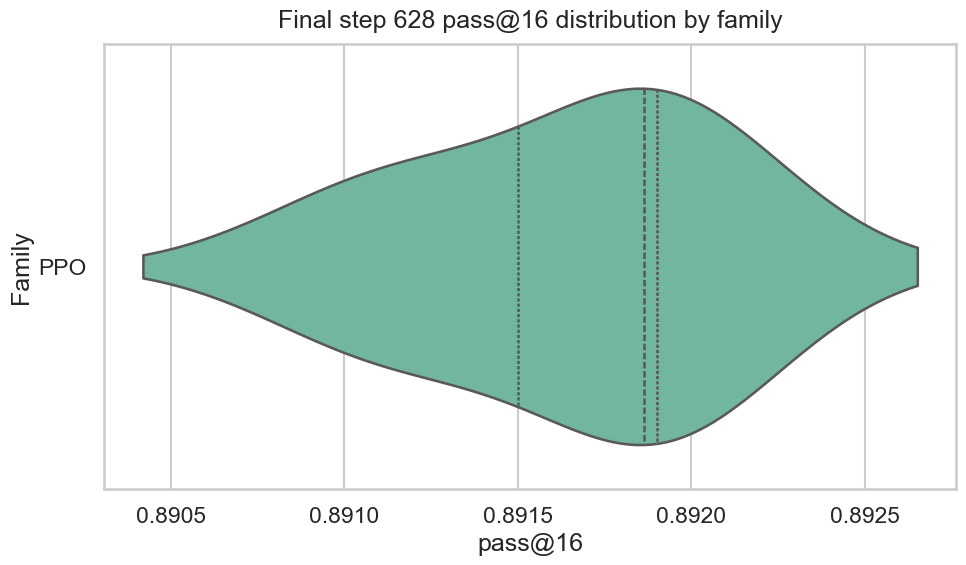

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


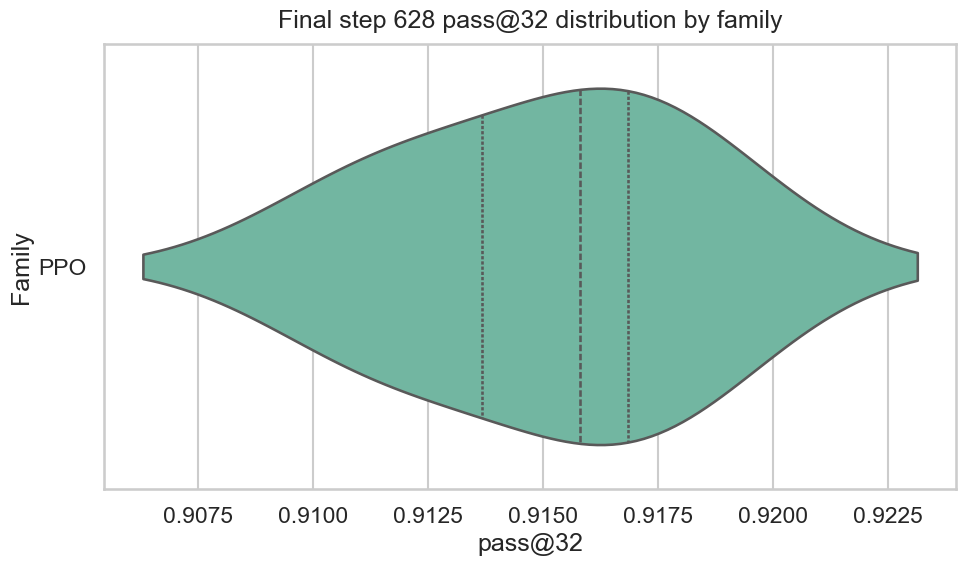

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


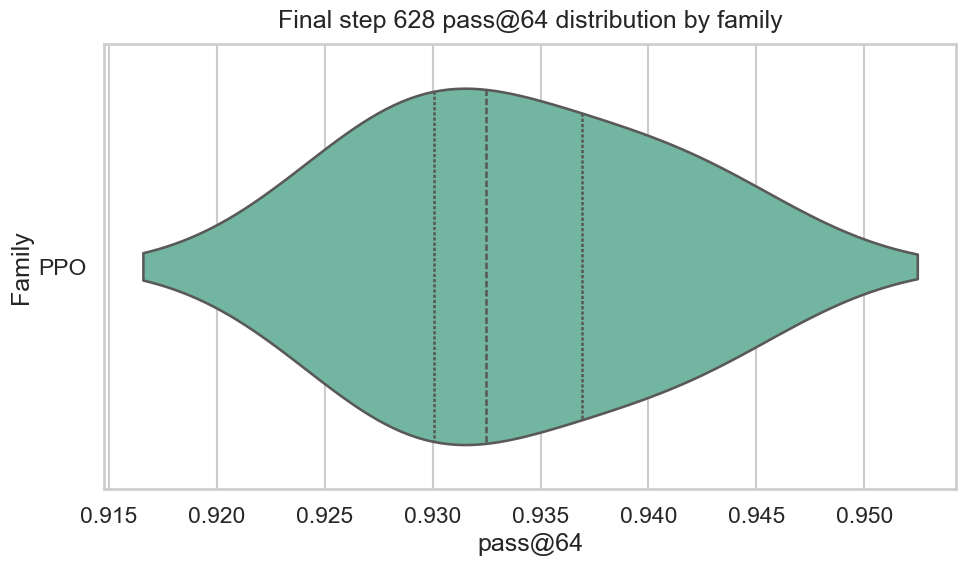

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2382624057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')


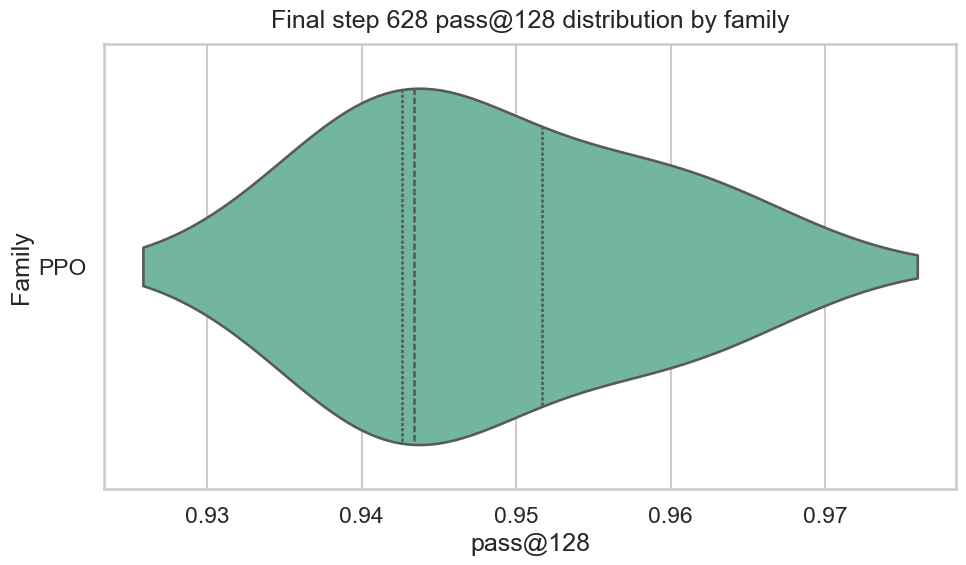

In [4]:

# Plot set B: final-step distribution by family
for metric in passk_metrics:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=final_df, x=metric, y='family', inner='quartile', palette='Set2')
    plt.title(f"Final step {final_step} {metric} distribution by family")
    plt.xlabel(metric)
    plt.ylabel('Family')
    plt.tight_layout()
    plt.show()
    plt.close()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2096273811.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='variant', palette='coolwarm')


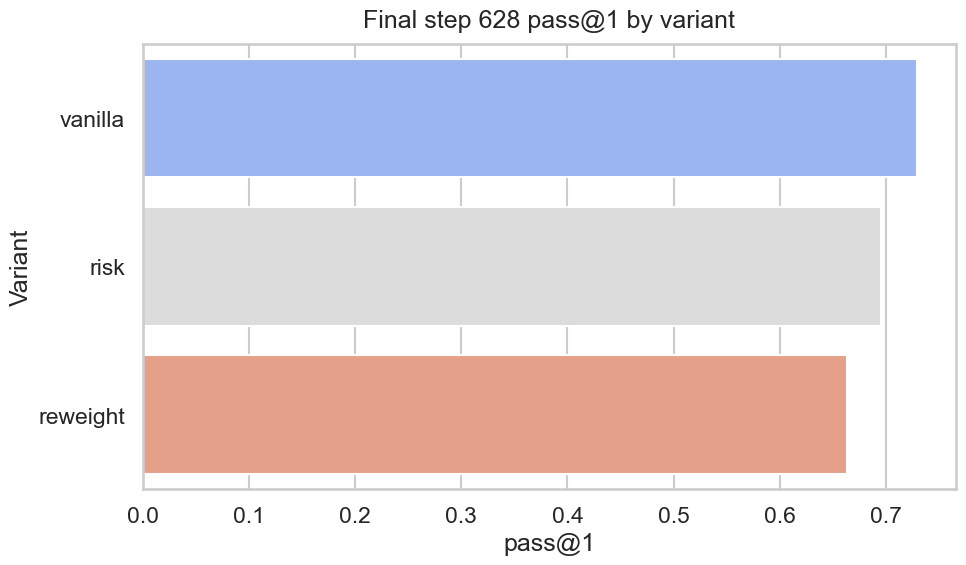

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2096273811.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='variant', palette='coolwarm')


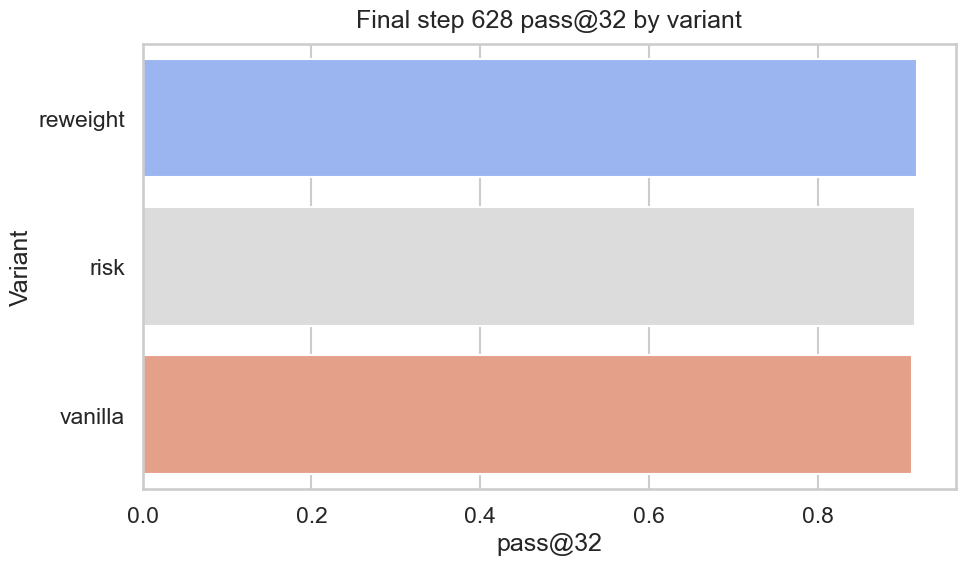

In [5]:

# Plot set C: variant comparison (risk/reweight/vanilla)
for metric in ['pass@1', 'pass@32']:
    plt.figure(figsize=(10, 6))
    order = (
        final_df.groupby('variant', as_index=False)[metric]
        .mean()
        .sort_values(metric, ascending=False)
    )
    sns.barplot(data=order, x=metric, y='variant', palette='coolwarm')
    plt.title(f"Final step {final_step} {metric} by variant")
    plt.xlabel(metric)
    plt.ylabel('Variant')
    plt.tight_layout()
    plt.show()
    plt.close()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2031714593.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='cvar', palette='crest')


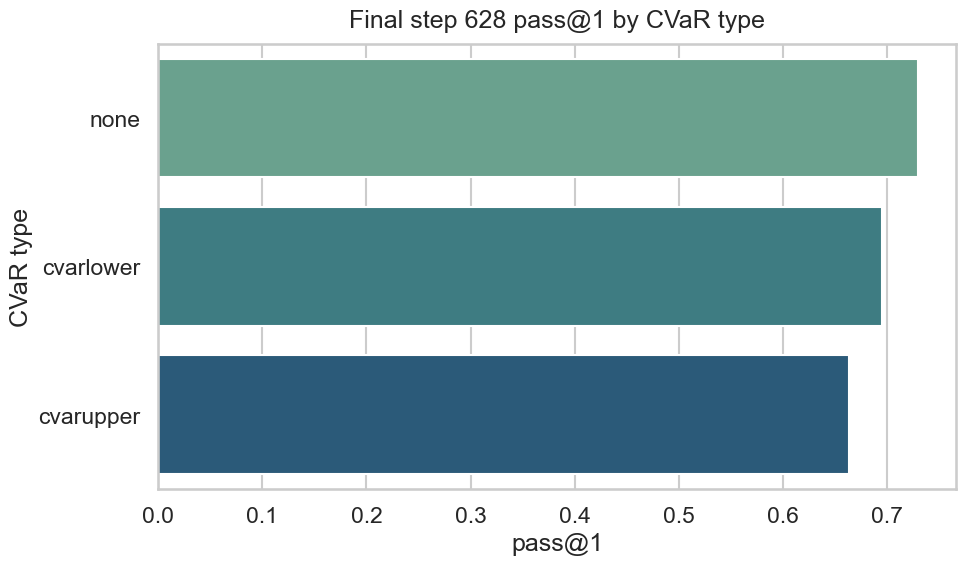

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94761/2031714593.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x=metric, y='cvar', palette='crest')


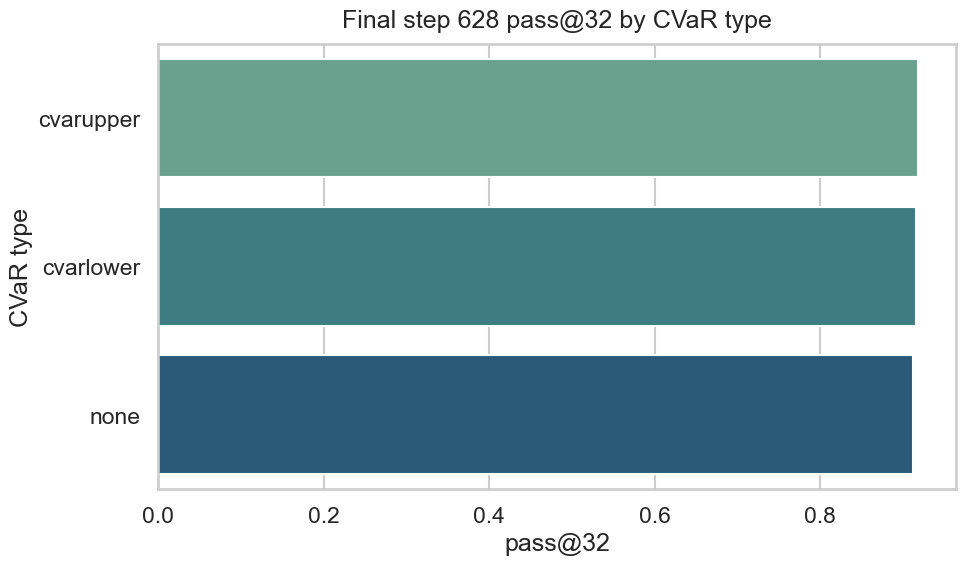

In [6]:

# Plot set D: CVaR type comparison
for metric in ['pass@1', 'pass@32']:
    plt.figure(figsize=(10, 6))
    order = (
        final_df.groupby('cvar', as_index=False)[metric]
        .mean()
        .sort_values(metric, ascending=False)
    )
    sns.barplot(data=order, x=metric, y='cvar', palette='crest')
    plt.title(f"Final step {final_step} {metric} by CVaR type")
    plt.xlabel(metric)
    plt.ylabel('CVaR type')
    plt.tight_layout()
    plt.show()
    plt.close()
